In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('transact_18_22.csv')


data = data.drop(columns=['mcc', 'group', 'value', 'card'], errors='ignore')

data = data.groupby(['date', 'client'], as_index=False).agg({
        'amt': 'sum'
})

data['date'] = pd.to_datetime(data['date'], errors='coerce')
data = data.set_index('date')
data.head()

,client,amt
date,,
2018-01-01,3845,1775.00
2018-01-01,5044,13259.00
2018-01-01,6908,350.00
2018-01-01,8332,246.39
2018-01-01,12014,199.00


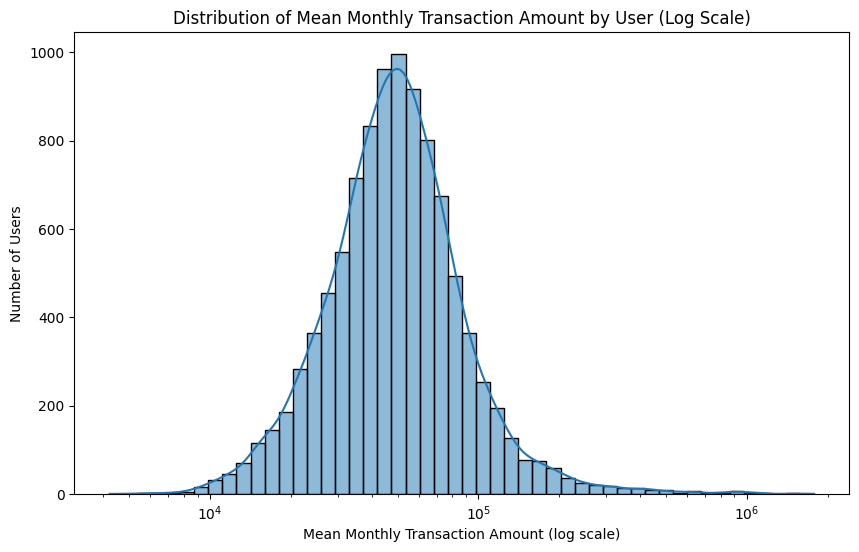

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Calculate monthly totals per client
data['month'] = data.index.to_period('M')
monthly_totals = data.groupby(['client', 'month'])['amt'].sum().reset_index()

# Compute mean monthly amount per client
mean_per_client = monthly_totals.groupby('client')['amt'].mean().reset_index()

# Plot distribution with log x-axis
plt.figure(figsize=(10, 6))
sns.histplot(
    data=mean_per_client, 
    x='amt', 
    kde=True, 
    bins=50, 
    log_scale=10  # Base-10 log scale for x-axis
)
plt.title('Distribution of Mean Monthly Transaction Amount by User (Log Scale)')
plt.xlabel('Mean Monthly Transaction Amount (log scale)')
plt.ylabel('Number of Users')

# Optional: Format x-axis ticks for better readability
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'$10^{int(np.log10(x))}$')) 

plt.show()

In [33]:
len(data)

8171169

In [34]:
len(pd.unique(data['client']))

10000

In [5]:
def get_client_df(client_id):

    client_df = data[data['client'] == client_id].copy()

    client_df = client_df.drop(columns=['client'], errors='ignore')

    start_date = client_df.index.min()

    end_date = pd.Timestamp('2020-03-15')

#     end_date = client_df.index.max()

    full_range = pd.date_range(
        start=start_date,
        end=end_date,
        freq='D'
    )

    client_df = client_df.reindex(full_range)
    client_df['amt'] = client_df['amt'].fillna(0)
    client_df['date'] = client_df.index.values
    client_df = client_df.reset_index()
    client_df = client_df.drop(columns=['index'], errors='ignore')
    return client_df

In [4]:
all_clients = data['client'].unique()

zero_ratios = []
for client_id in all_clients:
    client_df = get_client_df(client_id)
    total_days = len(client_df)
    zero_days = (client_df['amt'] == 0).sum()
    zero_ratio = zero_days / total_days
    zero_ratios.append({'client': client_id, 'zero_ratio': zero_ratio, 'total_days': total_days, 'zero_days': zero_days})

zero_ratio_df = pd.DataFrame(zero_ratios)
zero_ratio_df = zero_ratio_df.sort_values('zero_ratio')

In [199]:
zero_ratio_df[zero_ratio_df['client'] == 5044]

,client,zero_ratio,total_days,zero_days
1,5044,0.420455,1672,703


In [6]:
zero_ratio_df[15:30]

,client,zero_ratio,total_days,zero_days
695,2117702,0.099071,1615,160
28,119449,0.102809,1673,172
60,208625,0.103179,1667,172
9142,2962043,0.105034,1609,169
9831,1506446,0.105817,1616,171
1517,267065,0.106627,1660,177
6763,830030,0.108527,1677,182
549,1662478,0.109113,1668,182
9271,207417,0.110241,1660,183
1235,3149408,0.110514,1674,185


In [7]:
zero_ratio_df[30:50]

,client,zero_ratio,total_days,zero_days
439,1377677,0.118031,1686,199
4803,2483222,0.119501,1682,201
5901,2136576,0.119559,1631,195
4046,2853439,0.122337,1643,201
140,426999,0.122912,1676,206
9681,1592655,0.124079,1628,202
328,978146,0.124555,1686,210
2143,2054824,0.124703,1684,210
396,1251908,0.125148,1686,211
9868,1413751,0.125852,1613,203


In [201]:
data.head(7)

,client,amt
date,,
2018-01-01,3845,1775.00
2018-01-01,5044,13259.00
2018-01-01,6908,350.00
2018-01-01,8332,246.39
2018-01-01,12014,199.00
2018-01-01,17092,45.00
2018-01-01,17711,252.70


In [118]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def create_features(df):
    """Create time-based features and ensure proper formatting"""
    df['date'] = pd.to_datetime(df['date'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    
    df['week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
    df['week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['day_of_month']/31)
    df['month_cos'] = np.cos(2 * np.pi * df['day_of_month']/31)
    
    for lag in [1, 7, 30]:
        df[f'lag_{lag}'] = df['amt'].shift(lag)
    
    df['rolling_7d_mean'] = df['amt'].rolling(7).mean()
    df['rolling_30d_mean'] = df['amt'].rolling(30).mean()
    
    return df.drop(columns=['date']).dropna()

def prepare_data(client_id, data, test_size=0.2):
    """Prepare data for specific client"""
    client_df = data[data['client'] == client_id].copy()
    client_df = create_features(client_df.sort_values('date'))
    
    cols = ['amt'] + [col for col in client_df.columns if col != 'amt']
    client_df = client_df[cols]
    
    split_idx = int(len(client_df) * (1 - test_size))
    train = client_df.iloc[:split_idx]
    test = client_df.iloc[split_idx:]
    
    return train, test

def create_sequences(data, window_size=30):
    """Create input-output sequences for LSTM"""
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data.iloc[i:i+window_size, 1:].values)
        y.append(data.iloc[i+window_size, 0])
    return np.array(X), np.array(y)

class HistoricalMeanBaseline:
    def __init__(self):
        self.history = []
    
    def predict(self):
        return np.mean(self.history) if self.history else 0
    
    def update(self, actual):
        self.history.append(actual)

def train_and_evaluate(client_id, data):
    train, test = prepare_data(client_id, data)
    
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    X_train, y_train = create_sequences(pd.DataFrame(train_scaled, columns=train.columns))
    X_test, y_test = create_sequences(pd.DataFrame(test_scaled, columns=test.columns))

    model = Sequential([
        LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.2),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5)
    history = model.fit(X_train, y_train, epochs=50, 
                       validation_split=0.2, 
                       callbacks=[early_stop],
                       verbose=0)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_pred = scaler.inverse_transform(
        np.concatenate([train_pred, np.zeros((len(train_pred), train.shape[1]-1))], axis=1)
    )[:, 0]
    
    test_pred = scaler.inverse_transform(
        np.concatenate([test_pred, np.zeros((len(test_pred), test.shape[1]-1))], axis=1)
    )[:, 0]
    
    baseline = HistoricalMeanBaseline()
    baseline_preds = []
    for i in range(len(test)):
        baseline_preds.append(baseline.predict())
        baseline.update(test.iloc[i, 0])
    
    metrics = {
        'LSTM Train MAE': mean_absolute_error(train.iloc[30:, 0], train_pred),
        'LSTM Test MAE': mean_absolute_error(test.iloc[30:, 0], test_pred),
        'Baseline Test MAE': mean_absolute_error(test.iloc[30:, 0], baseline_preds[30:]),
        'LSTM Test RMSE': np.sqrt(mean_squared_error(test.iloc[30:, 0], test_pred)),
        'Baseline Test RMSE': np.sqrt(mean_squared_error(test.iloc[30:, 0], baseline_preds[30:]))
    }
    
    plt.figure(figsize=(15, 6))
    plt.plot(test.index[30:], test.iloc[30:, 0], label='Actual')
    plt.plot(test.index[30:], test_pred, label='LSTM Forecast')
    plt.plot(test.index[30:], baseline_preds[30:], label='Baseline', alpha=0.7)
    plt.title(f'Forecast Comparison for Client {client_id}')
    plt.legend()
    plt.show()
    
    return metrics

client_id = 390989
metrics = train_and_evaluate(client_id, data)
print("\nPerformance Metrics:")
print(pd.Series(metrics).to_string(float_format="%.2f"))

ValueError: could not convert string to float: 'food'

In [6]:
data[data['client'] == 390989]

,client,card,date,amt,mcc,group,value
0,390989,3048567,2018-01-01,878.00,5814,food,survival
362,390989,3048567,2018-01-01,1520.00,5812,food,survival
739,390989,3048567,2018-01-01,1520.00,4121,travel,socialization
947,390989,3048567,2018-01-01,790.00,5533,travel,socialization
2401,390989,3048567,2018-01-02,2700.00,5814,food,survival
...,...,...,...,...,...,...,...
19260035,390989,6721953,2022-08-13,327.00,7311,misc,socialization
19260039,390989,6721953,2022-08-13,325.00,4121,travel,socialization
19260537,390989,6721953,2022-08-13,3232.69,5541,travel,socialization
19261171,390989,6721953,2022-08-14,1.00,7311,misc,socialization


In [4]:
date_range = pd.date_range(
    start=client_df['date'].min(),
    end=client_df['date'].max(),
    freq='D'
)
daily_spend_full = daily_spend.set_index('date').reindex(date_range, fill_value=0).reset_index()
daily_spend_full.columns = ['date', 'amt']


NameError: name 'client_df' is not defined

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(daily_spend_full['date'], daily_spend_full['amt'], marker='o', linestyle='-')
plt.title(f'Daily Transaction Amount for Client {390989}')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.grid(True)
plt.show()

In [22]:
chosen_client = 3377993
client_df = get_client_df(chosen_client)
client_df.head()

,amt,date
0,635.0,2018-03-26
1,1002.0,2018-03-27
2,2547.0,2018-03-28
3,585.0,2018-03-29
4,468.0,2018-03-30


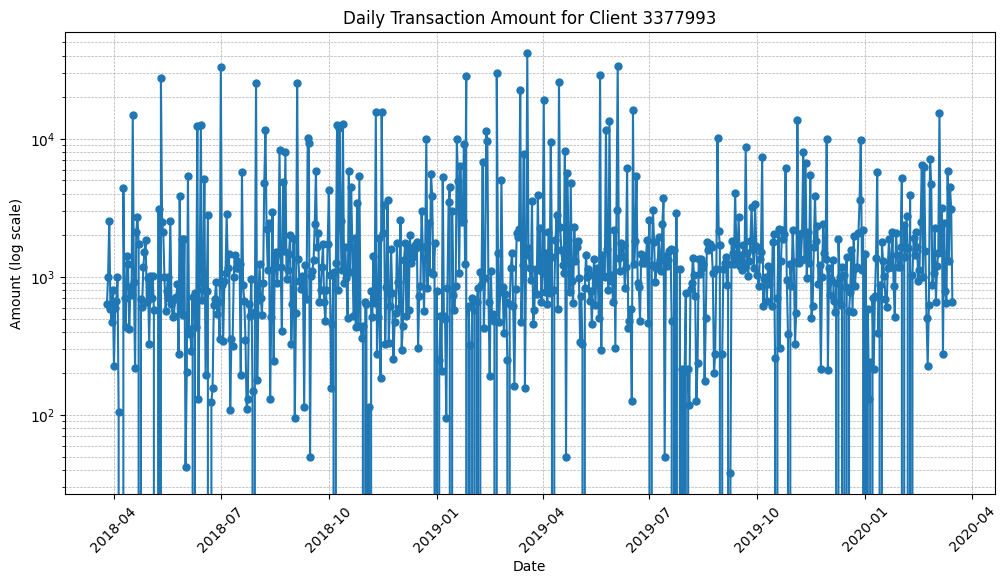

In [26]:
import pandas as pd
import matplotlib.pyplot as plt



plt.figure(figsize=(12, 6))
plt.plot(client_df['date'], client_df['amt'], marker='o', linestyle='-', markersize=5)
plt.title(f'Daily Transaction Amount for Client {chosen_client}')
plt.xlabel('Date')
plt.ylabel('Amount (log scale)')  # Уточняем подпись оси
plt.xticks(rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)  # Включаем сетку для обеих осей
plt.yscale('log')  # Логарифмический масштаб по Y
plt.show()

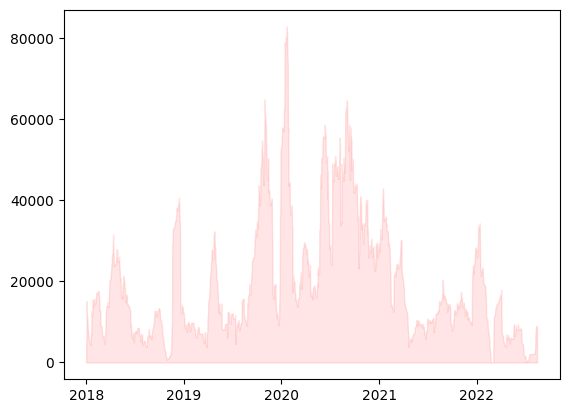

In [107]:

window_size = 30
daily_spend_full = daily_spend_full.set_index('date')
daily_spend_full['rolling_avg'] = daily_spend_full['amt'].rolling('30D').mean()
plt.fill_between(daily_spend_full.index, daily_spend_full['rolling_avg'], color='red', alpha=0.1)

# Отслеживание тренда (отсуствует)

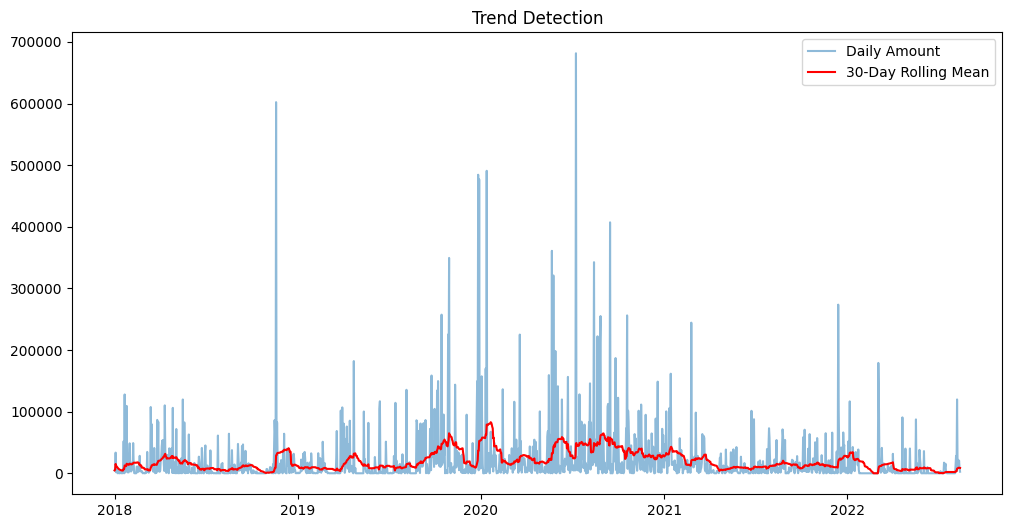

In [108]:

daily_spend_full['rolling_30d'] = daily_spend_full['amt'].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(12, 6))

plt.plot(daily_spend_full['amt'], label='Daily Amount', alpha=0.5)
plt.plot(daily_spend_full['rolling_30d'], label='30-Day Rolling Mean', color='red')
plt.title('Trend Detection')
plt.legend()
plt.show()

In [73]:
from pymannkendall import original_test

result = original_test(daily_spend_full['amt'].values)

print(f"Trend: {'Increasing' if result.trend == 'increasing' else 'Decreasing' if result.trend == 'decreasing' else 'No Trend'}")
print(f"p-value: {result.p}")
print(f"Test Statistic (S): {result.s}")

Trend: No Trend
p-value: 0.2674569153879014
Test Statistic (S): -25499.0


# Исследуем сезонность

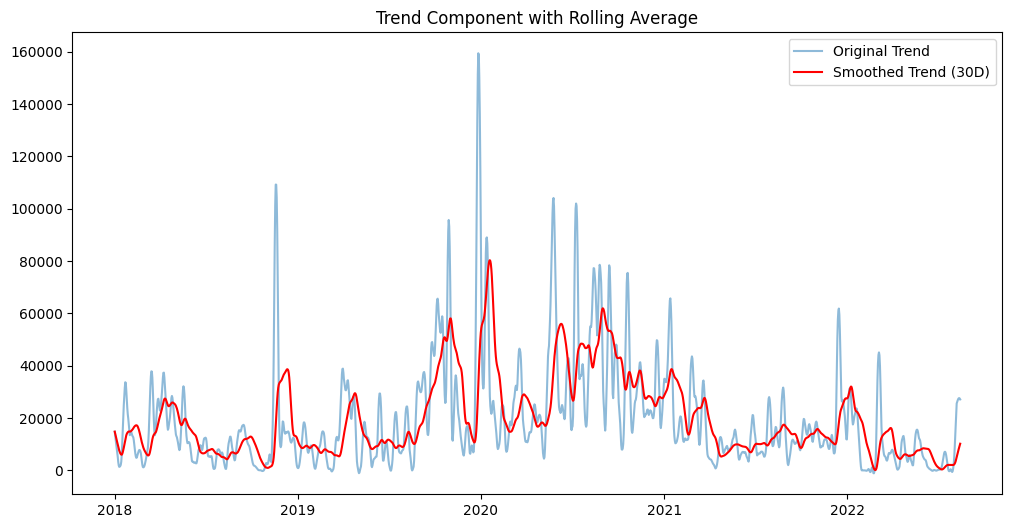

In [83]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
stl = STL(daily_spend_full['amt'], seasonal=7)
result = stl.fit()


trend = result.trend
seasonal = result.seasonal
residual = result.resid

smoothed_trend = trend.rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(trend, label='Original Trend', alpha=0.5)
plt.plot(smoothed_trend, label='Smoothed Trend (30D)', color='red')
plt.legend()
plt.title('Trend Component with Rolling Average')
plt.show()

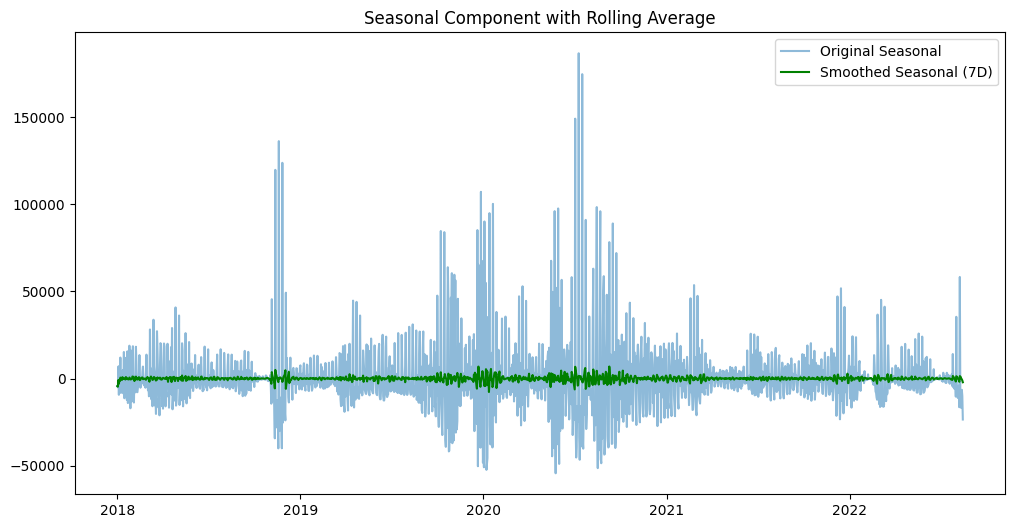

In [84]:
smoothed_seasonal = seasonal.rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(seasonal, label='Original Seasonal', alpha=0.5)

plt.plot(smoothed_seasonal, label='Smoothed Seasonal (7D)', color='green')
plt.legend()
plt.title('Seasonal Component with Rolling Average')
plt.show()

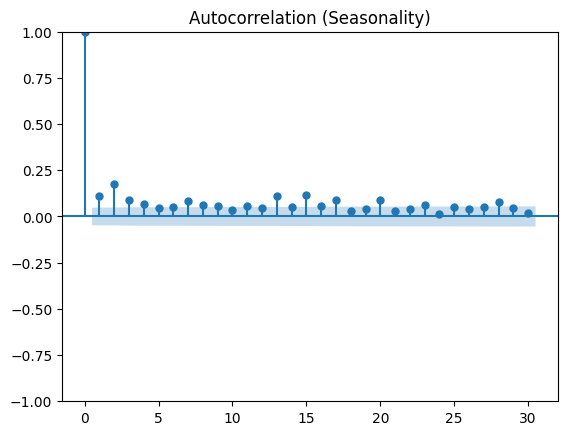

In [69]:
plot_acf(daily_spend_full['amt'], lags=30)
plt.title('Autocorrelation (Seasonality)')
plt.show()

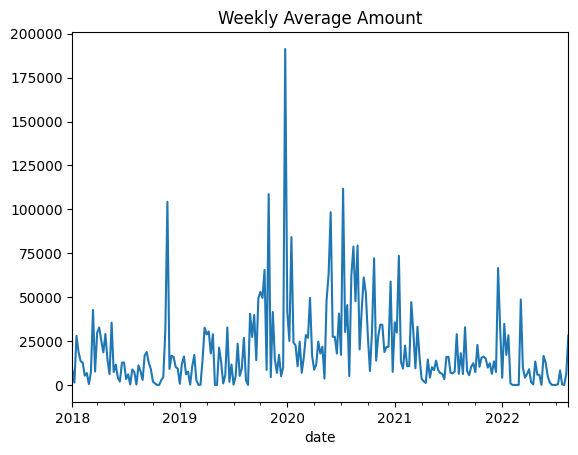

In [85]:
weekly_avg = daily_spend_full['amt'].resample('W').mean()
weekly_avg.plot(title='Weekly Average Amount')
plt.show()

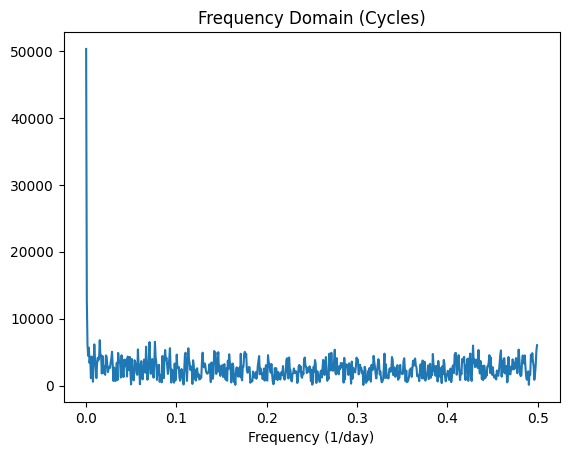

In [72]:
from scipy.fft import fft, fftfreq
import numpy as np

nonzero_amt = daily_spend_full[daily_spend_full['amt'] > 0]['amt']
N = len(nonzero_amt)
yf = fft(nonzero_amt.values)
xf = fftfreq(N, 1)[:N//2]

plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Frequency Domain (Cycles)')
plt.xlabel('Frequency (1/day)')
plt.show()

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import periodogram
from matplotlib.dates import DateFormatter
from statsmodels.tsa.seasonal import STL

def analyze_seasonality(clients, data, min_date='2018-01-01', max_date='2022-12-31'):
    """
    Analyze and visualize seasonality for multiple clients with:
    - Periodograms (weekly/monthly)
    - Weekly/monthly patterns
    - STL decomposition
    - Zero-inclusive handling
    """
    for client_id in clients:
        client_df = data[data['client'] == client_id].copy()
        if client_df.empty:
            print(f"Client {client_id} not found, skipping...")
            continue
            
        client_df['date'] = pd.to_datetime(client_df['date'])
        full_range = pd.date_range(min_date, max_date, freq='D')
        daily_amt = (
            client_df.groupby('date')['amt']
            .sum()
            .reindex(full_range, fill_value=0)
        )

        fig = plt.figure(figsize=(18, 16))
        gs = fig.add_gridspec(4, 2)
        
        ax1 = fig.add_subplot(gs[0, :])
        f, Pxx = periodogram(daily_amt, fs=1)
        periods = 1/f[1:]
        ax1.semilogy(periods, Pxx[1:], color='navy')
        ax1.axvline(7, color='red', linestyle='--', alpha=0.5, label='Weekly')
        ax1.axvline(30, color='green', linestyle=':', label='Monthly')
        ax1.set_title(f'Client {client_id} - Power Spectral Density')
        ax1.set_xlabel('Period (days)')
        ax1.set_ylabel('Power')
        ax1.set_xlim(1, 60)
        ax1.legend()
        ax1.grid(True)

        ax2 = fig.add_subplot(gs[1, 0])
        weekly_pattern = (
            daily_amt.groupby(daily_amt.index.dayofweek)
            .mean()
            .rolling(window=3, center=True)
            .mean()
        )
        days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        ax2.plot(days, weekly_pattern, marker='o', color='darkorange')
        ax2.set_title('Weekly Spending Pattern')
        ax2.grid(True)

        ax3 = fig.add_subplot(gs[1, 1])
        monthly_amt = daily_amt.resample('M').sum()
        ax3.plot(monthly_amt.index, monthly_amt.values, marker='o', color='purple')
        ax3.set_title('Monthly Aggregates')
        ax3.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
        ax3.grid(True)

        try:
            stl = STL(daily_amt, period=30)
            res = stl.fit()
            
            ax4 = fig.add_subplot(gs[2, 0])
            ax4.plot(res.trend, color='blue')
            ax4.set_title('STL Trend Component')
            
            ax5 = fig.add_subplot(gs[2, 1])
            ax5.plot(res.seasonal, color='green')
            ax5.set_title('STL Seasonal Component')
            
            ax6 = fig.add_subplot(gs[3, :])
            ax6.plot(res.resid, color='red')
            ax6.set_title('STL Residual Component')
            
        except Exception as e:
            print(f"STL decomposition failed for client {client_id}: {str(e)}")
            plt.delaxes(fig.add_subplot(gs[2, 0]))
            plt.delaxes(fig.add_subplot(gs[2, 1]))
            plt.delaxes(fig.add_subplot(gs[3, :]))

        plt.tight_layout()
        plt.show()

        metrics_data = {
            'Client ID': [client_id],
            'Weekly Power': [Pxx[np.abs(periods - 7).argmin()]],
            'Monthly Power': [Pxx[np.abs(periods - 30).argmin()]],
            'Zero Days %': [(daily_amt == 0).mean() * 100]
        }
        print(pd.DataFrame(metrics_data).to_string(index=False, float_format="%.2f"))
        print("\n" + "="*80 + "\n")


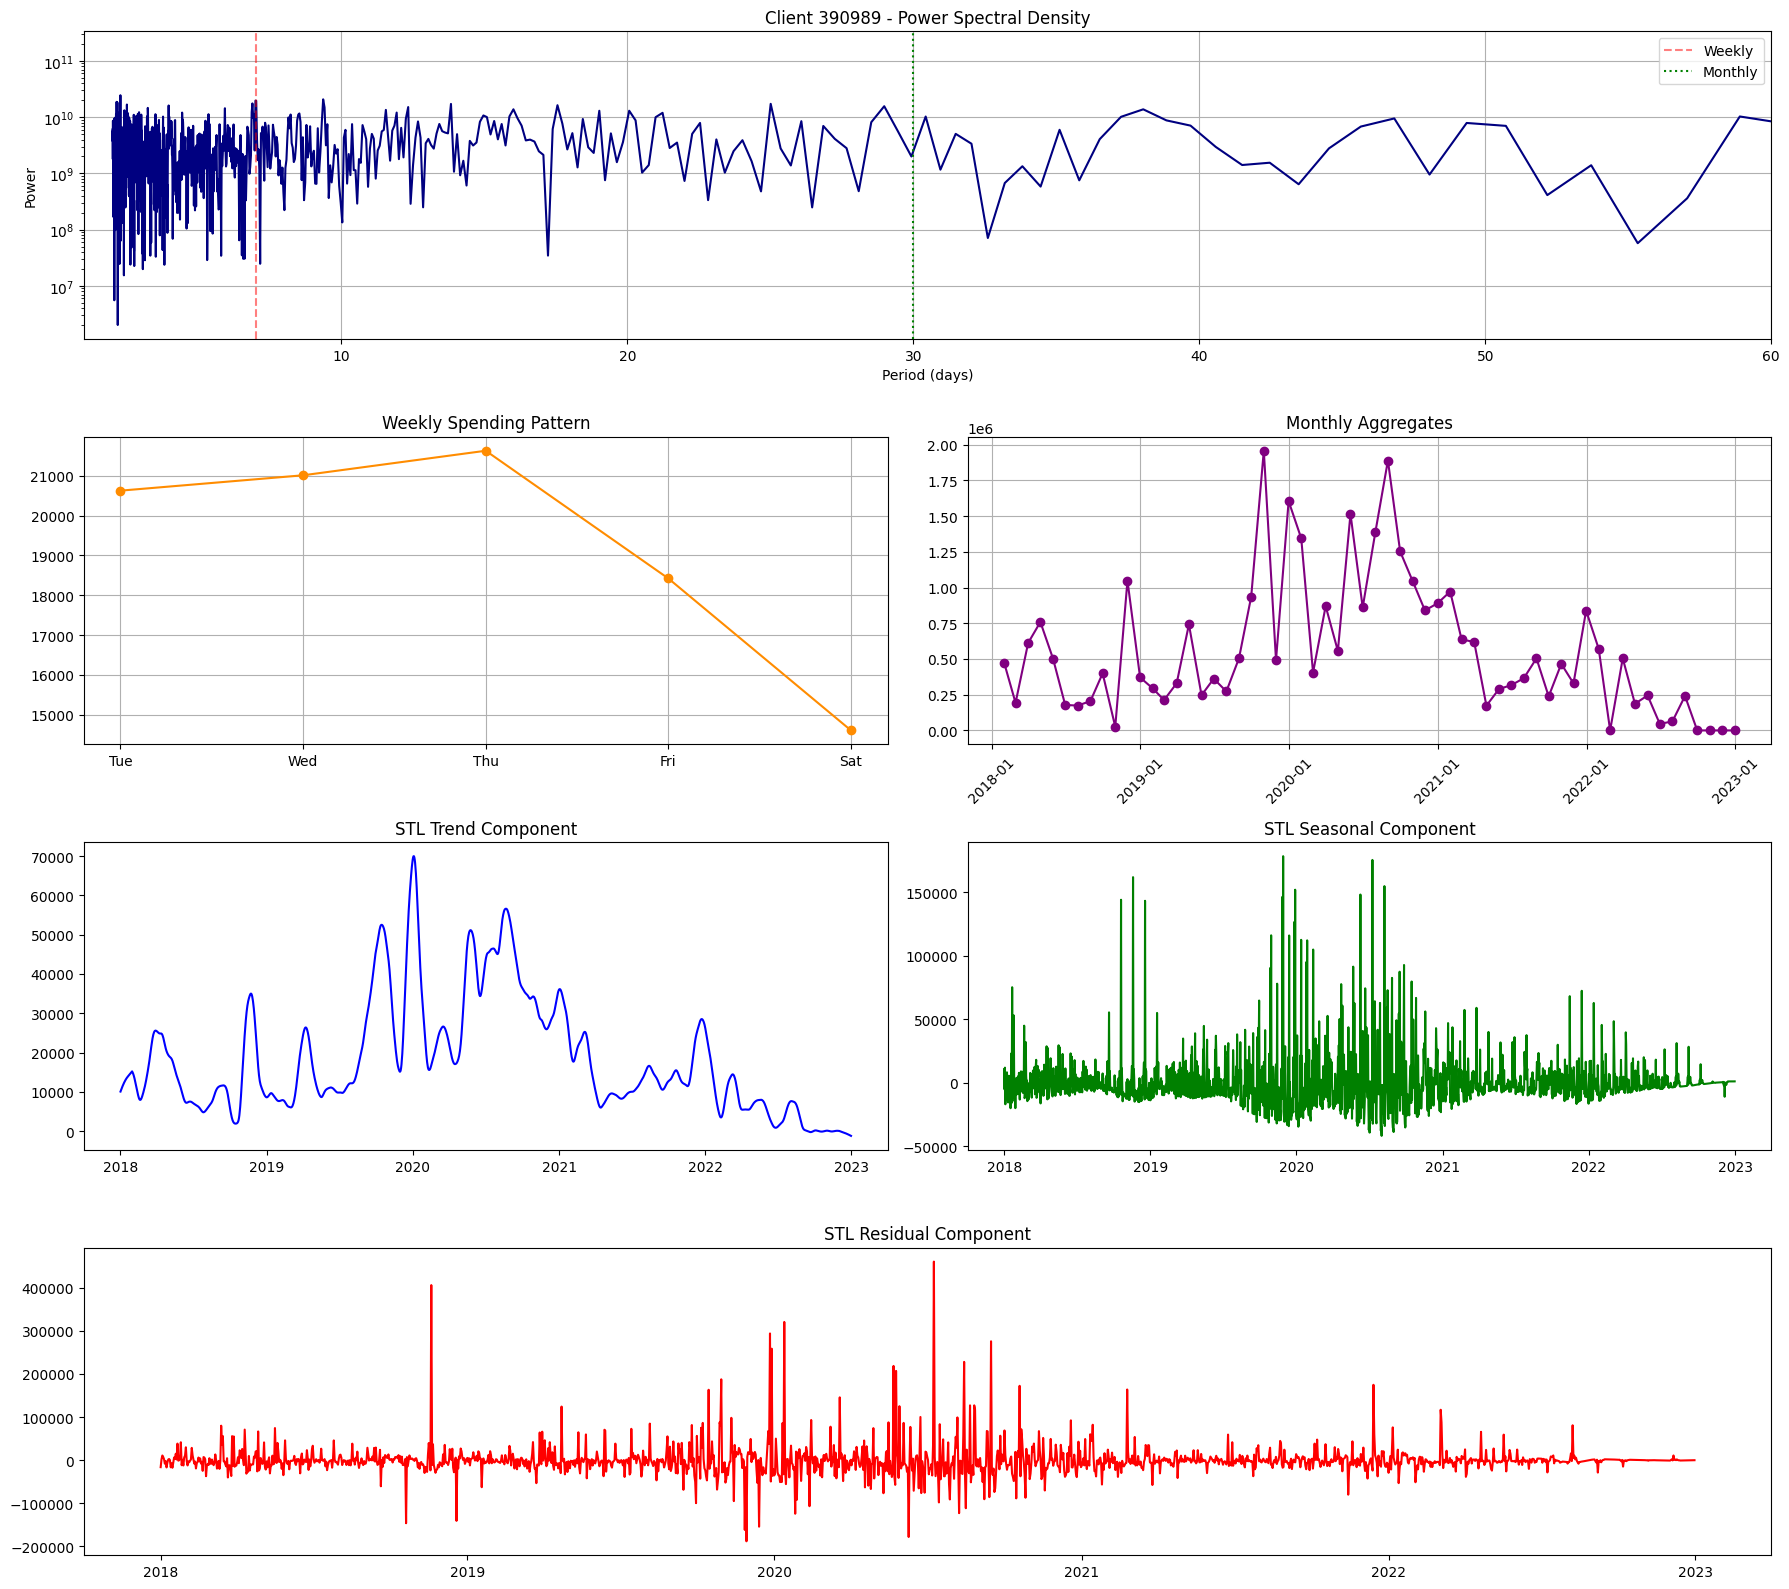

 Client ID   Weekly Power  Monthly Power  Zero Days %
    390989 19485851105.30 10262297213.68        27.38




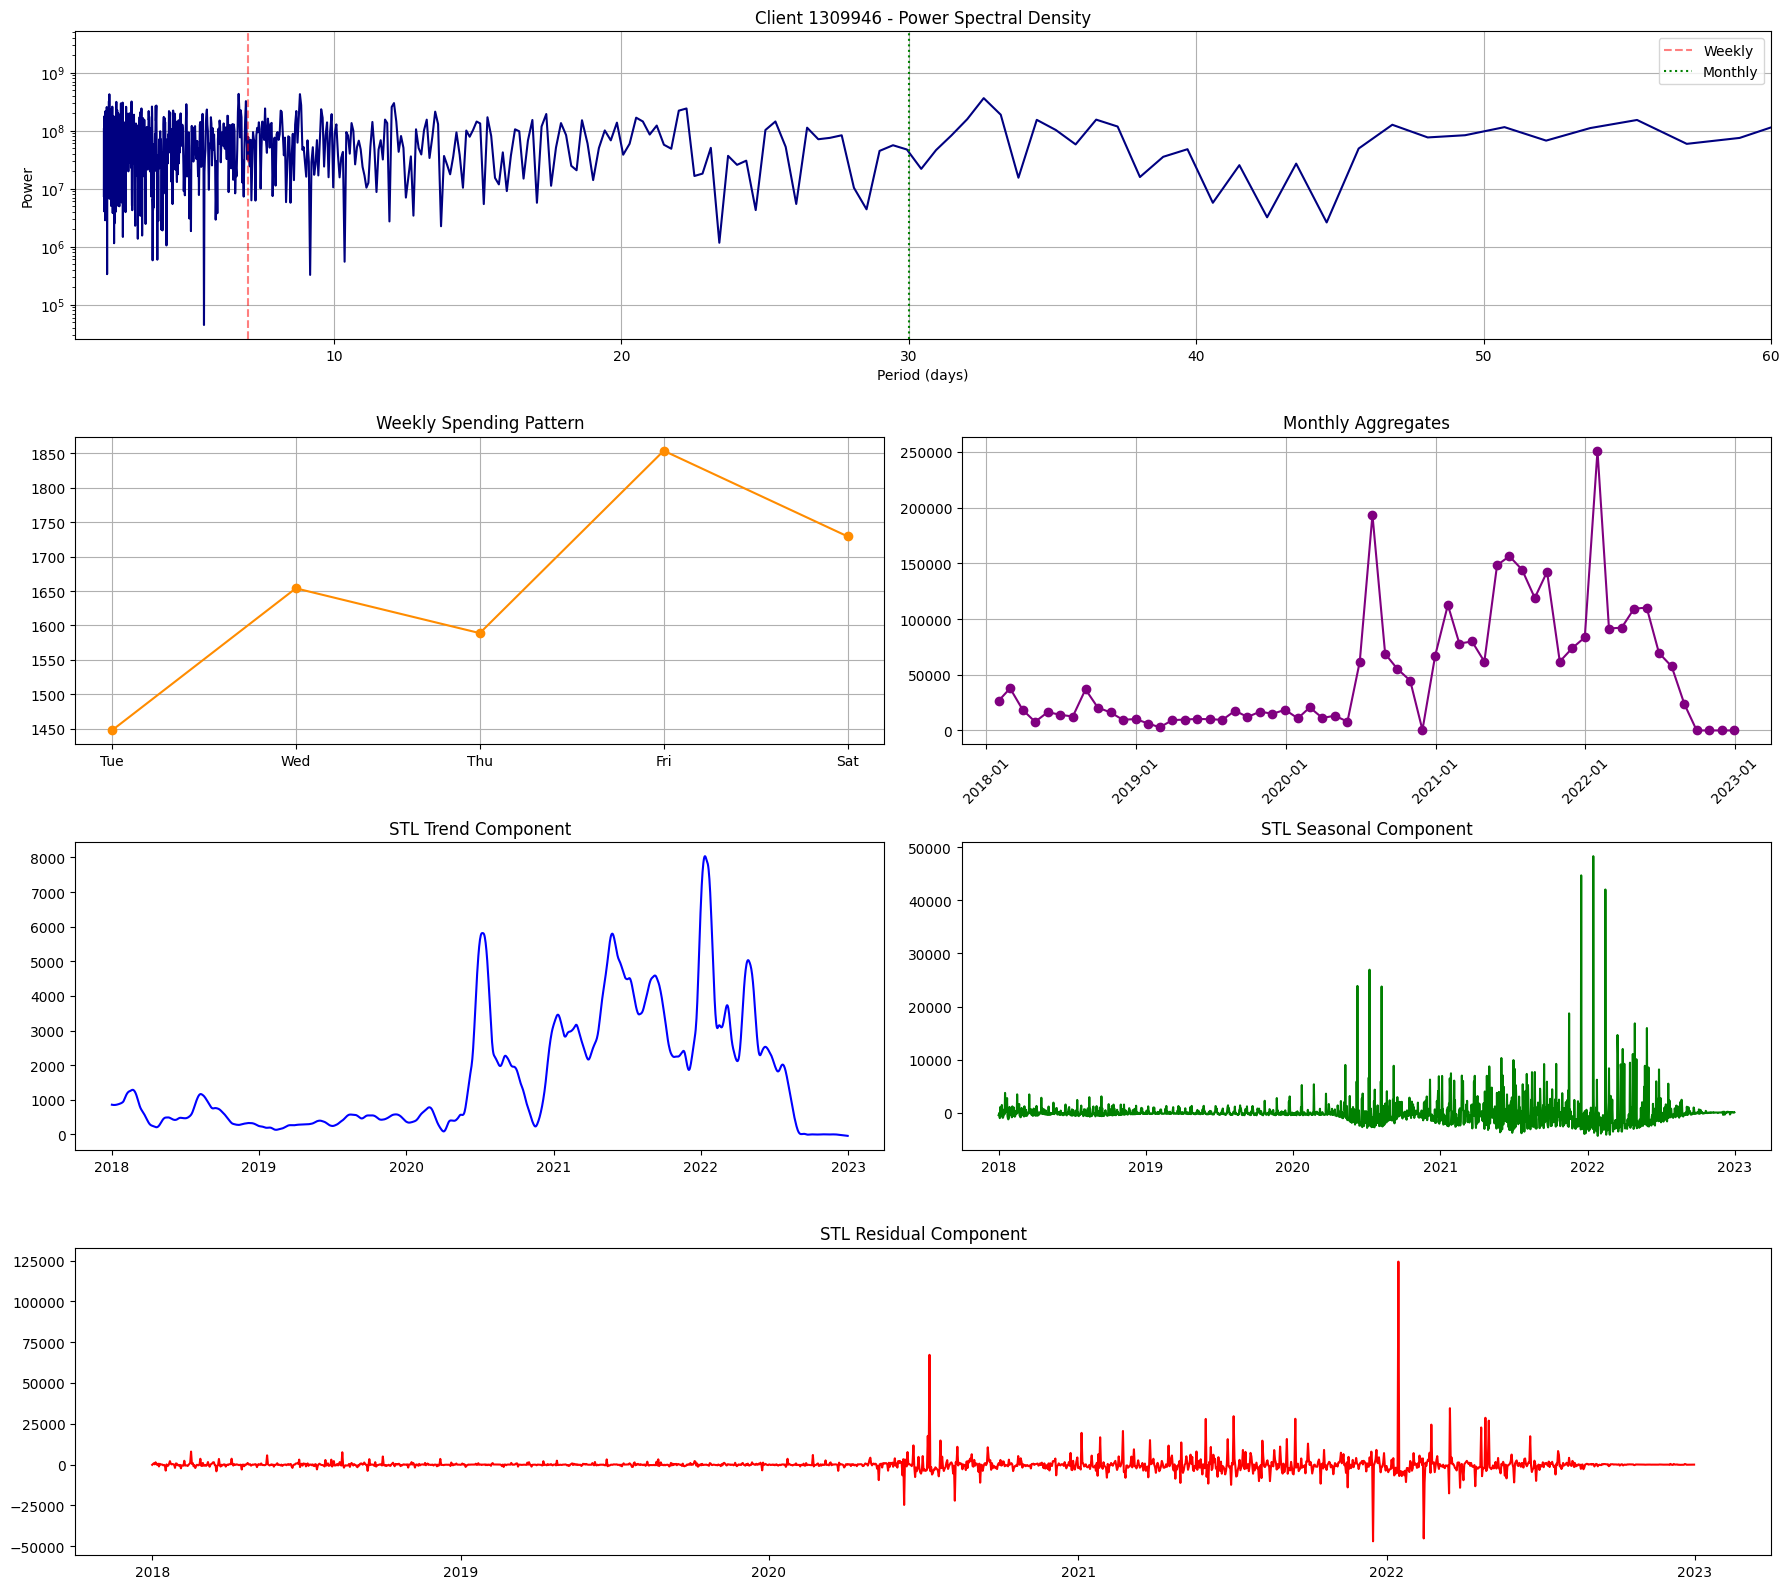

 Client ID  Weekly Power  Monthly Power  Zero Days %
   1309946   77395117.21    21870159.15        48.14




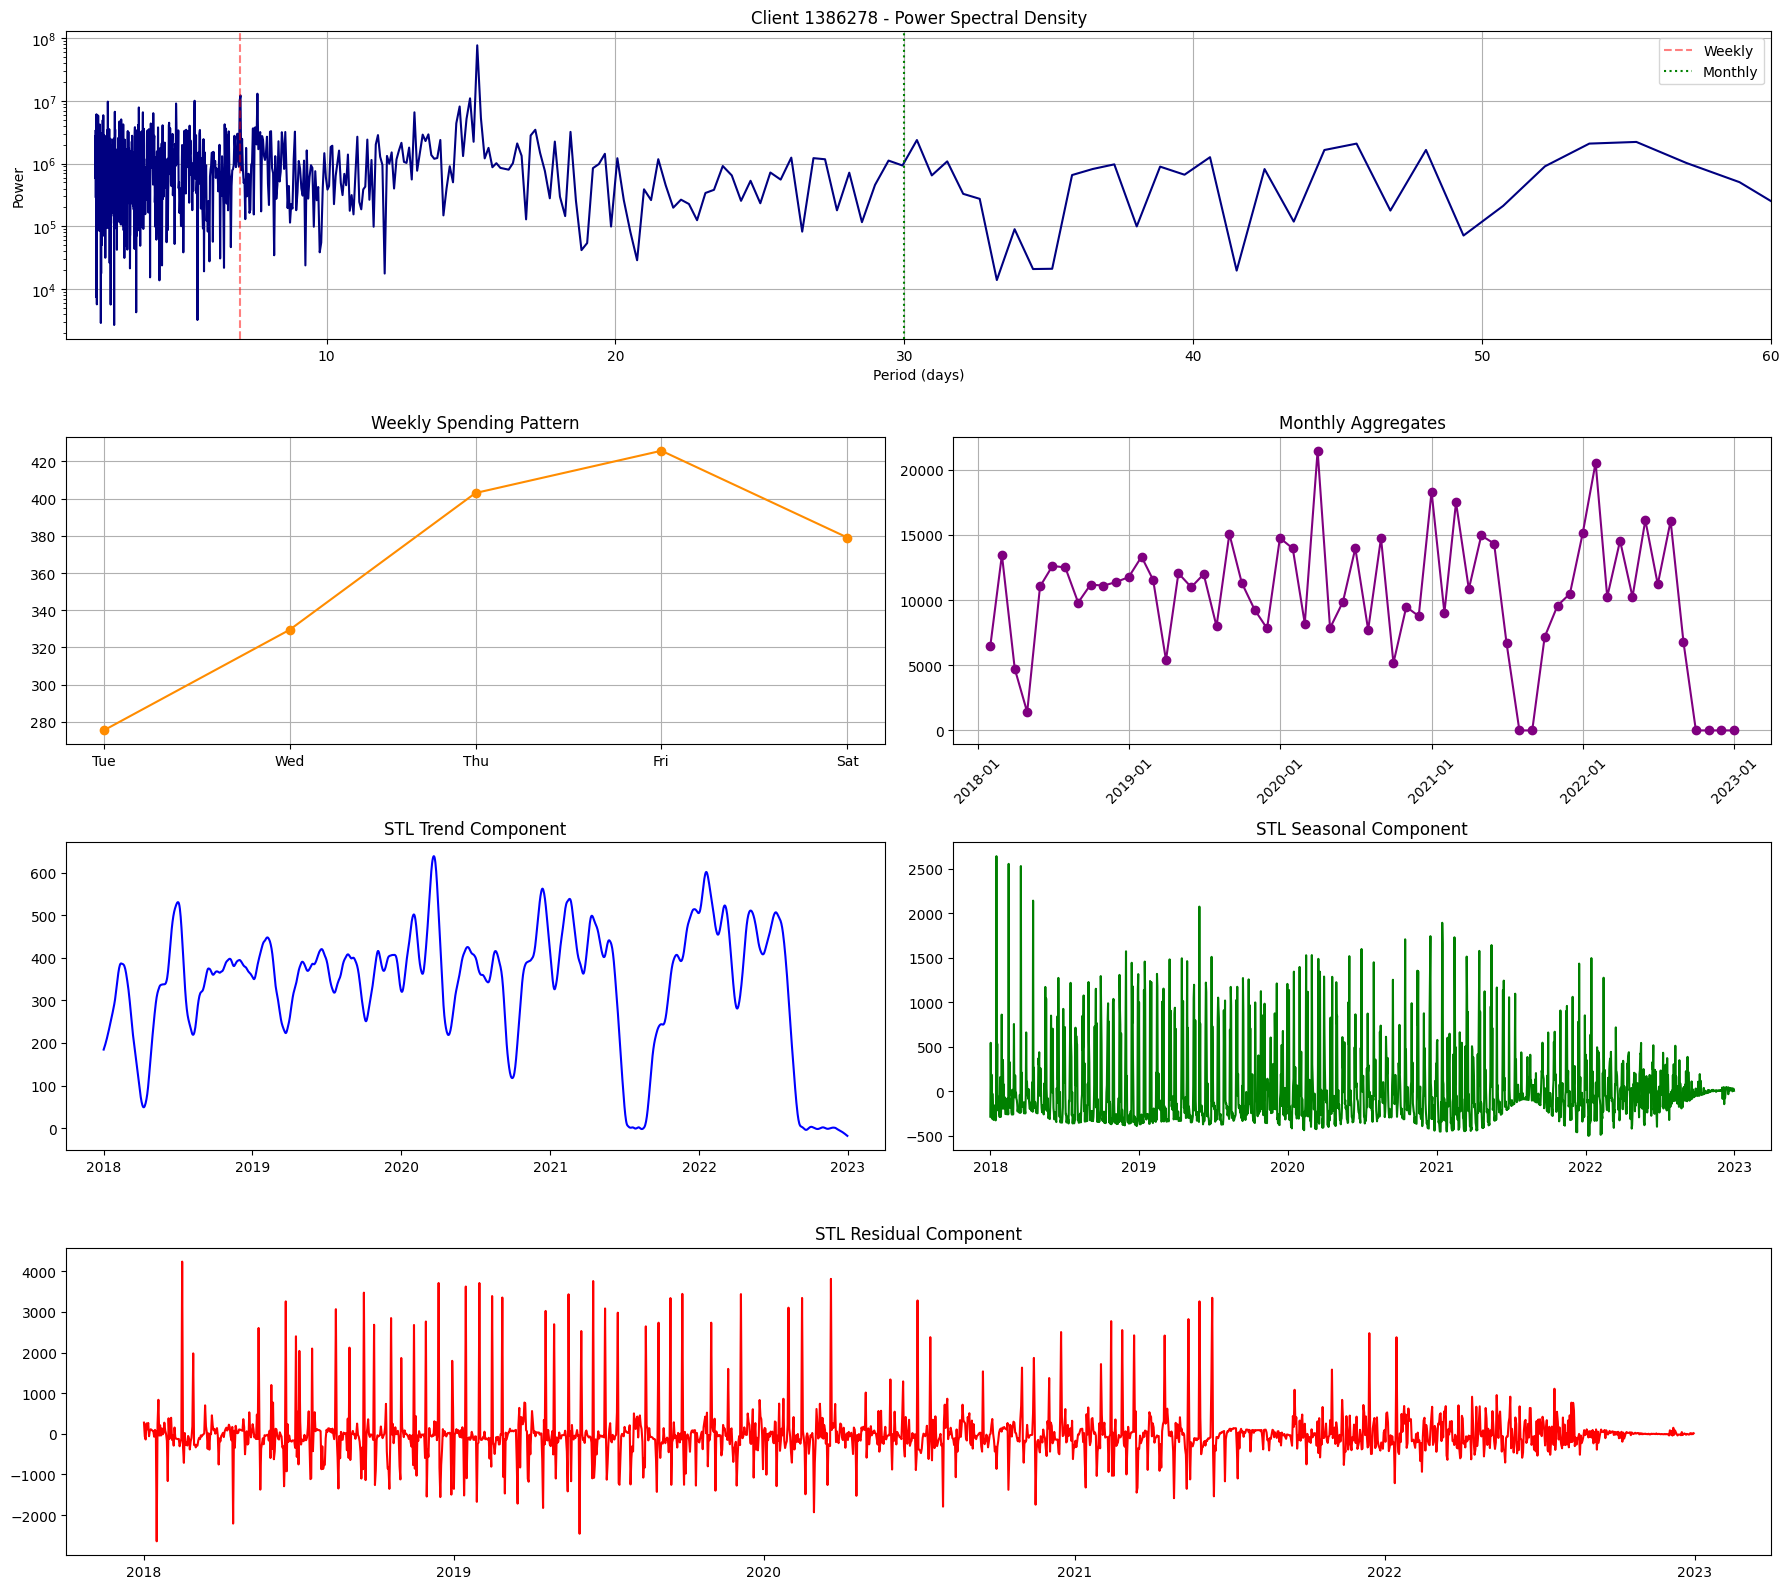

 Client ID  Weekly Power  Monthly Power  Zero Days %
   1386278   12219037.50     2372976.69        60.02




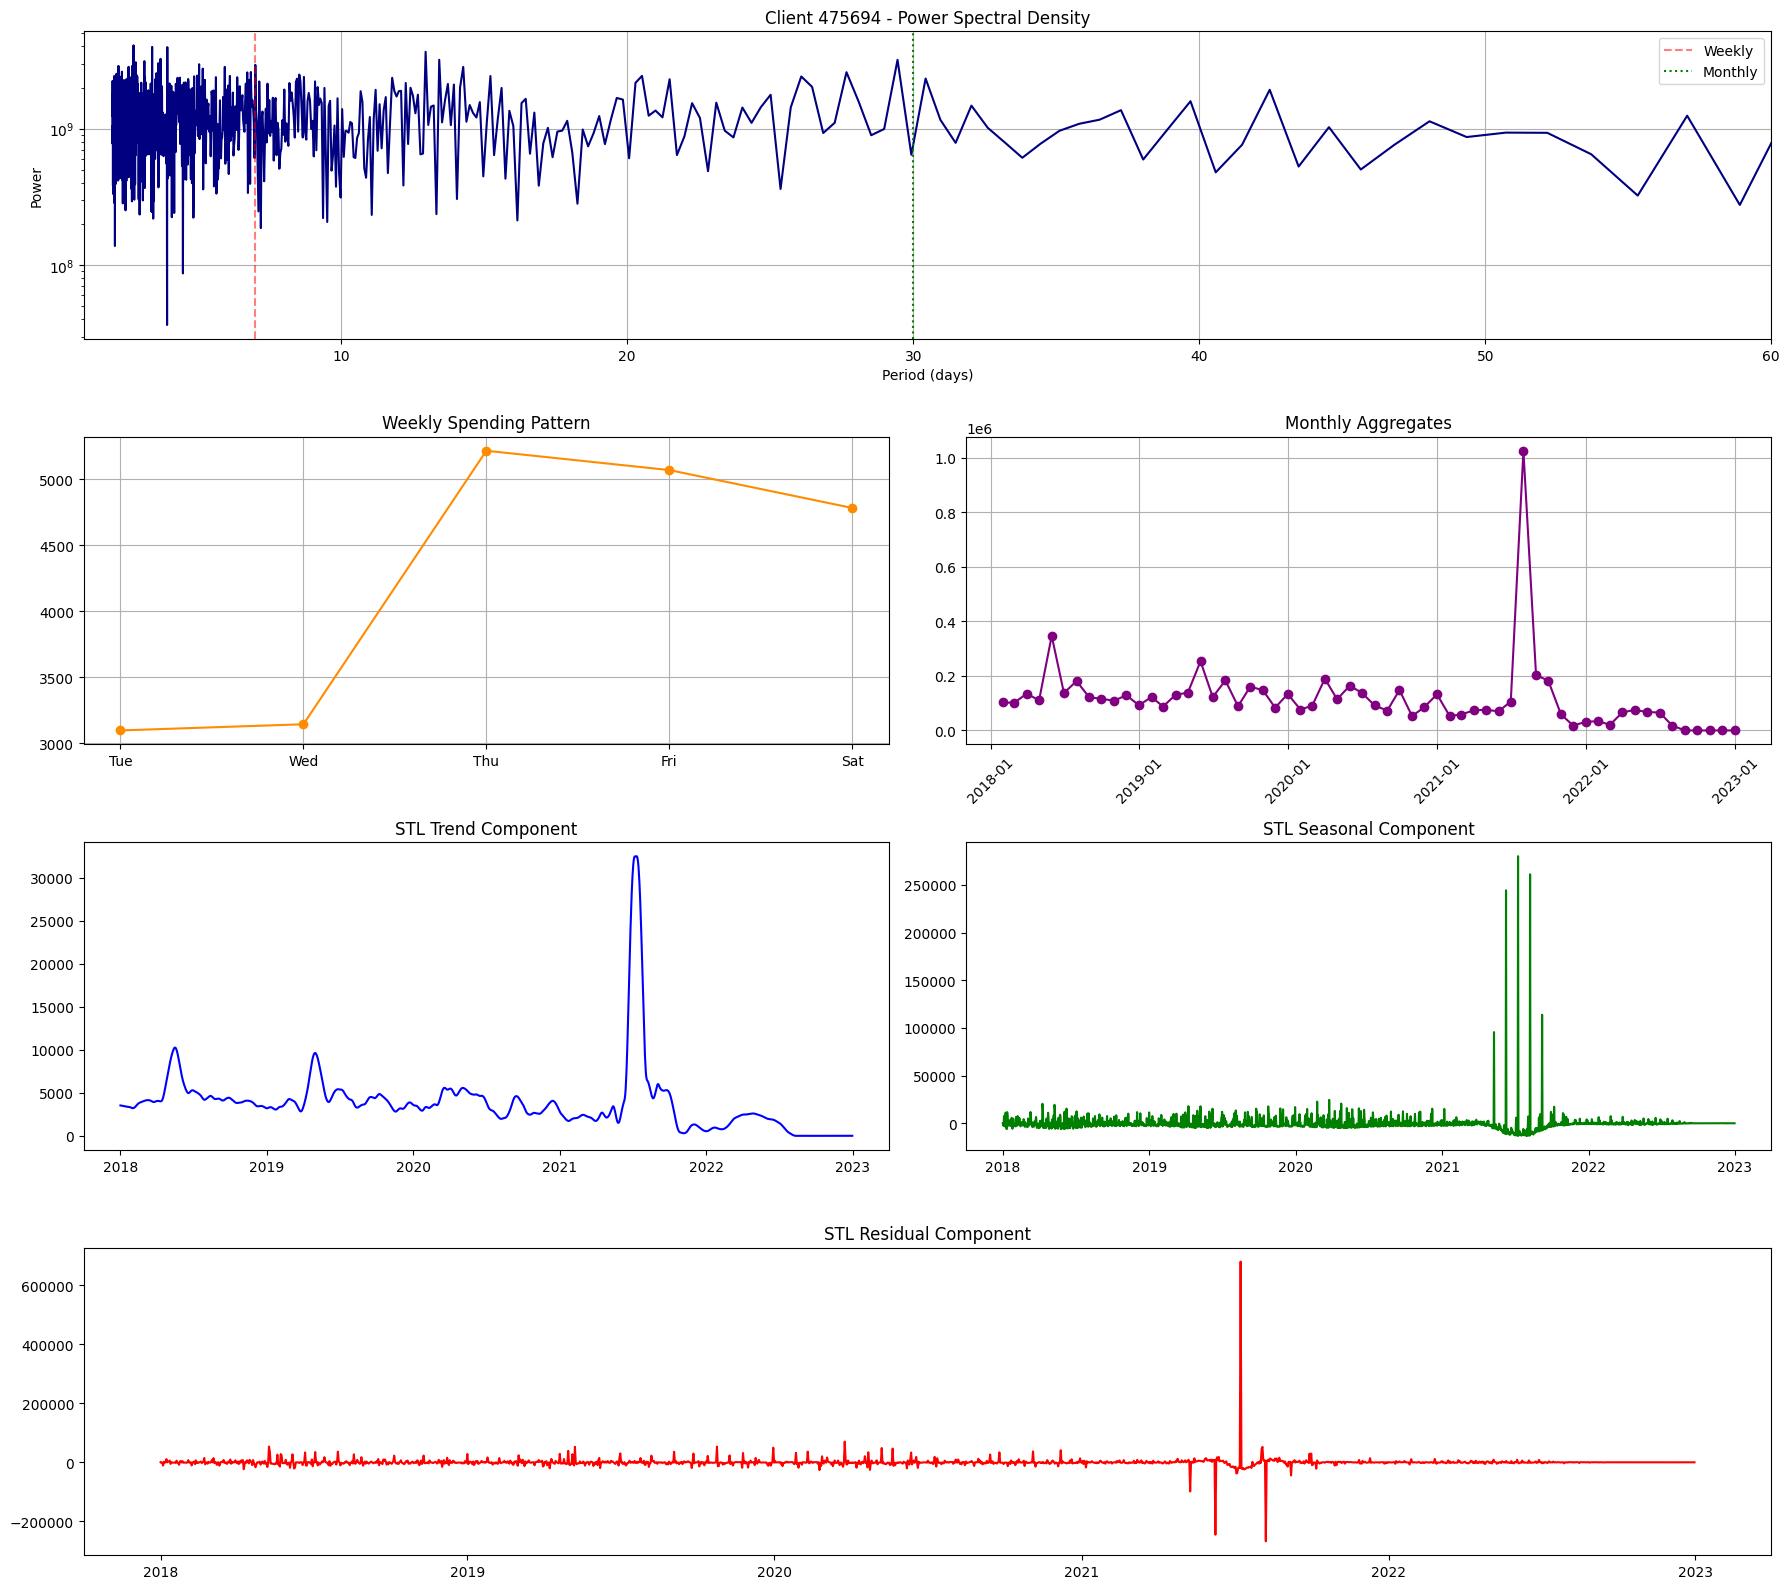

 Client ID  Weekly Power  Monthly Power  Zero Days %
    475694 1346570563.16  2329729503.16        50.49




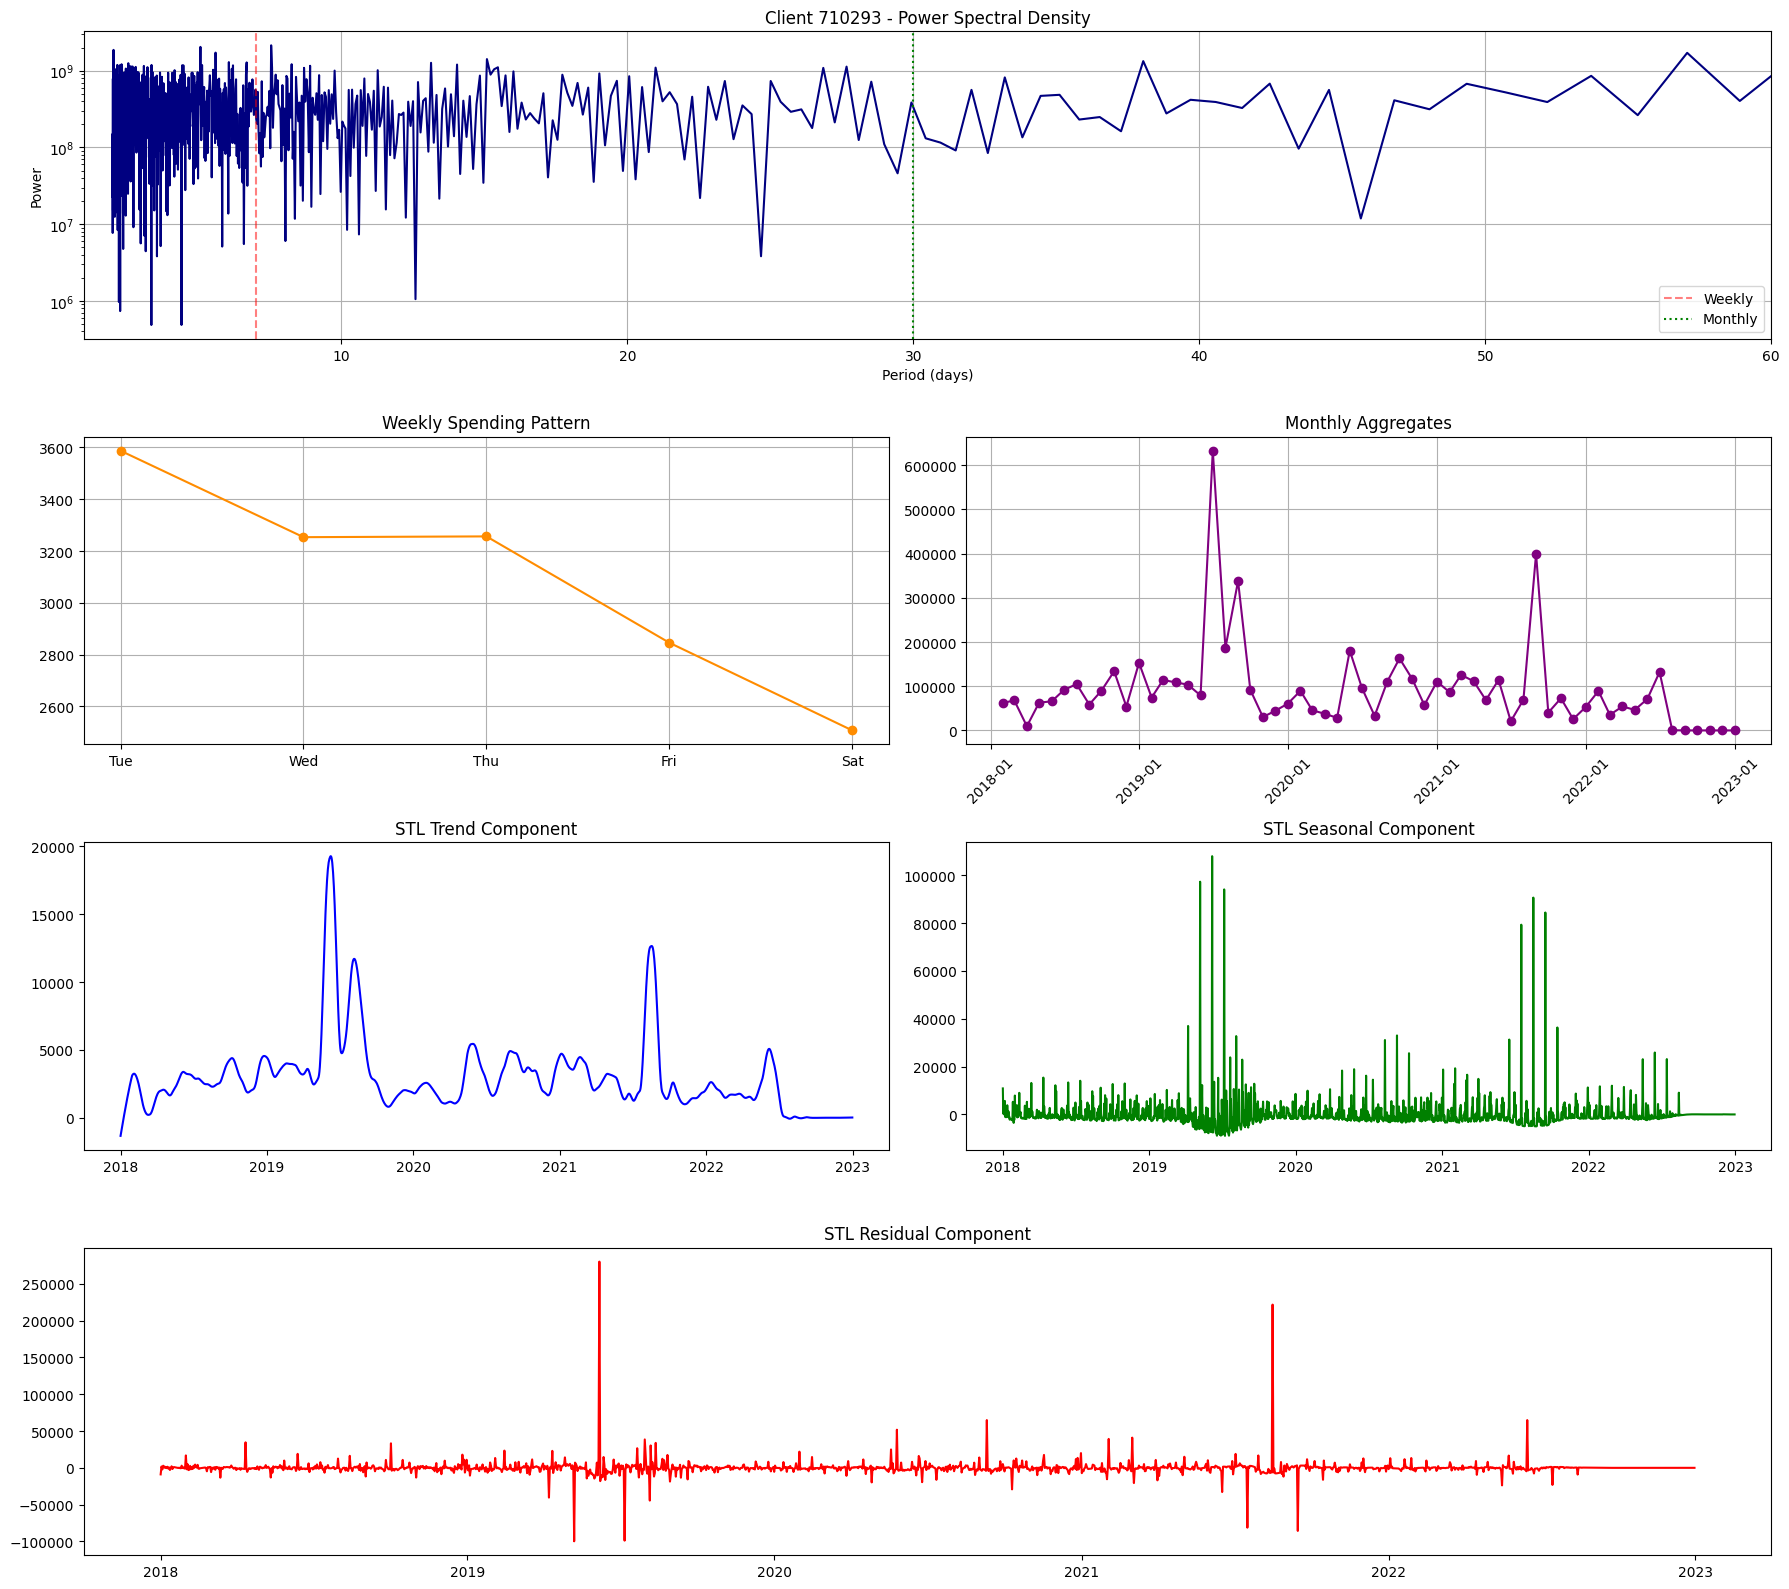

 Client ID  Weekly Power  Monthly Power  Zero Days %
    710293  233509238.97   131471127.77        47.59




In [114]:
# Example usage:
analyze_seasonality([390989, 1309946, 1386278, 475694, 710293], data)

In [169]:
class HistoricalMeanBaseline:
    def __init__(self):
        self.daily_history = {i: [] for i in range(7)}
    
    def update(self, date, actual):
        """Update model with new daily amount and its date"""
        day_of_week = date.weekday()  # Extract day of week (0-6)
        self.daily_history[day_of_week].append(actual)
    
    def predict(self, start_date, days=7):
        """Predict next 7 days using historical day-of-week averages"""
        predictions = []
        current_date = pd.to_datetime(start_date)
        
        for _ in range(days):
            day = current_date.weekday()

            if self.daily_history[day]:
                pred = np.mean(self.daily_history[day])
            else:
                all_values = [v for vals in self.daily_history.values() for v in vals]
                pred = np.mean(all_values) if all_values else 0
            
            predictions.append(pred)
            current_date += pd.Timedelta(days=1)
        
        return np.array(predictions)

In [173]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input


def create_features(df):
    """Add temporal and rolling features"""
    df['day_of_week'] = df.index.dayofweek
    df['days_since_nonzero'] = (df['amt'] > 0)[::-1].cumsum().shift(1).fillna(0)
    window_size = 7
    df['rolling_nonzero'] = df['amt'].gt(0).rolling(window=window_size).sum().fillna(0)
    df['rolling_amt'] = df['amt'].where(df['amt'] > 0).rolling(window=window_size).mean().fillna(0)
    return df
    
    return df.dropna()

def prepare_data(client_id, data):
    """Prepare data: 2 years train, next year test"""
    client_df = data[data['client'] == client_id].copy()
    client_df = client_df.drop(columns=['mcc', 'group', 'value', 'card'], errors='ignore')
    
    client_df = client_df.groupby('date', as_index=False).agg({
        'amt': 'sum'
    })
    client_df['date'] = pd.to_datetime(client_df['date'], errors='coerce')
    
    client_df = client_df.set_index('date')
    start_date = client_df.index.min()
    

    train_end = start_date + pd.DateOffset(years=2, months=6)
    test_end = train_end + pd.DateOffset(weeks=1)
    print(start_date, train_end, test_end)
    
    full_range = pd.date_range(
        start=start_date,
        end=test_end - pd.Timedelta(days=1),
        freq='D'
    )
    
    client_df = client_df.reindex(full_range)
    client_df['amt'] = client_df['amt'].fillna(0)
    
    train = client_df[(client_df.index >= start_date) & 
                     (client_df.index < train_end)]
    test = client_df[(client_df.index >= train_end) & 
                    (client_df.index < test_end)]
    
    if train.empty or test.empty:
        print(f"Insufficient data for client {client_id}")
        return None, None

    cols = ['amt'] + [col for col in client_df.columns if col != 'amt']
    return train[cols], test[cols]

def create_sequences(data, features, window_size=30, forecast_horizon=7):
    """Create sequences for multi-task learning (classification + regression)"""
    X, y_cls, y_reg = [], [], []
    data_values = data[features].values
    amt_values = data['amt'].values
    
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data_values[i:i+window_size])
        
        cls_target = (amt_values[i+window_size:i+window_size+forecast_horizon] > 0).astype(int)
        y_cls.append(cls_target)
        
        reg_target = amt_values[i+window_size:i+window_size+forecast_horizon]
        y_reg.append(reg_target)
    
    return np.array(X), np.array(y_cls), np.array(y_reg)


In [177]:
from tensorflow.keras import Model
client_id = 390989
train, test = prepare_data(client_id, data)

train = create_features(train)
test = create_features(test)

features = ['amt', 'day_of_week', 'rolling_nonzero', 'rolling_amt']
scaler_dict = {}


for feature in features:
    if feature == 'amt':
        non_zero_mask = train[feature] > 0
        scaler = RobustScaler()
        train.loc[non_zero_mask, feature] = scaler.fit_transform(train.loc[non_zero_mask, [feature]])
        scaler_dict[feature] = scaler
    elif feature != 'day_of_week':
        scaler = StandardScaler()
        train[feature] = scaler.fit_transform(train[[feature]])
        scaler_dict[feature] = scaler

for feature in features:
    if feature == 'amt':
        non_zero_mask = test_scaled[feature] > 0
        test_scaled.loc[non_zero_mask, feature] = scaler_dict[feature].transform(
            test_scaled.loc[non_zero_mask, [feature]]
        )
    elif feature != 'day_of_week':
        test_scaled[feature] = scaler_dict[feature].transform(test_scaled[[feature]])

        

X_train, y_train_cls, y_train_reg = create_sequences(train, features)

inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = LSTM(64, return_sequences=True)(inputs)
x = Dropout(0.3)(x)
x = LSTM(32)(x)

cls_output = Dense(7, activation='sigmoid', name='classification')(x)

reg_output = Dense(7, name='regression')(x)


model = Model(inputs=inputs, outputs=[cls_output, reg_output])
model.compile(
    loss={
        'classification': 'binary_crossentropy',
        'regression': 'mse'
    },
    metrics={
        'classification': 'accuracy',
        'regression': 'mae'
    },
    optimizer='adam'
)

2018-01-01 00:00:00 2020-07-01 00:00:00 2020-07-08 00:00:00


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [147]:
print("Zero days ratio:", (train['amt'] == 0).mean())

Zero days ratio: 0.19956140350877194


In [134]:
baseline = HistoricalMeanBaseline()
for date, row in train.iterrows():
    baseline.update(date, row['amt'])

In [135]:
test_start = test.index.min()
baseline_preds = baseline.predict(test_start)

In [175]:
import time

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_time = time.time()
history = model.fit(
    X_train,
    {'classification': y_train_cls, 'regression': y_train_reg},
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)
training_time = time.time() - start_time
print(f"Training Time (s): {training_time}")

Training Time (s): 25.581849575042725


In [127]:
y.shape

(876, 7)

In [176]:
seq_length = X_train.shape[1]
X_final = []

final_sequence = test_scaled[features].values[-seq_length:]
X_final.append(final_sequence)

X_final = np.array(X_final)

pred_cls, pred_reg = model.predict(X_final)

pred_amounts = scaler_dict['amt'].inverse_transform(pred_reg)

final_predictions = np.where(pred_cls > 0.5, 0, pred_amounts)

forecast = pd.DataFrame({
    'date': pd.date_range(start=test.index[-1] + pd.Timedelta(days=1), periods=7),
    'predicted_amount': final_predictions[0],
    'zero_probability': pred_cls[0]
})


forecast_dates = pd.date_range(start=test.index[0], periods=7)
actual = test['amt'].values[:7]


metrics_lstm = {
    'Annual MAE': mean_absolute_error(actual, predictions),
    'Annual RMSE': np.sqrt(mean_squared_error(actual, predictions)),
    'Worst Day Error': np.max(np.abs(actual - predictions)),
    'Best Day Accuracy': np.mean(np.isclose(actual, predictions, rtol=0.1))
}

metrics_baseline = {
    'Annual MAE': mean_absolute_error(actual, baseline_preds),
    'Annual RMSE': np.sqrt(mean_squared_error(actual, baseline_preds)),
    'Worst Day Error': np.max(np.abs(actual - baseline_preds)),
    'Best Day Accuracy': np.mean(np.isclose(actual, baseline_preds, rtol=0.1))
}


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 1 and 4 for '{{node functional_25_1/lstm_44_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](functional_25_1/lstm_44_1/strided_slice_1, functional_25_1/lstm_44_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [1,1], [4,256].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(1, 1), dtype=float32)
  • states=('tf.Tensor(shape=(1, 64), dtype=float32)', 'tf.Tensor(shape=(1, 64), dtype=float32)')
  • training=False

In [152]:
metrics_lstm

{'Annual MAE': 17238.865736607142,
 'Annual RMSE': 18261.230239173714,
 'Worst Day Error': 22282.677421875,
 'Best Day Accuracy': 0.0}

In [142]:
metrics_baseline

{'Annual MAE': 10877.184530240751,
 'Annual RMSE': 12395.00222785146,
 'Worst Day Error': 18738.1693129771,
 'Best Day Accuracy': 0.14285714285714285}

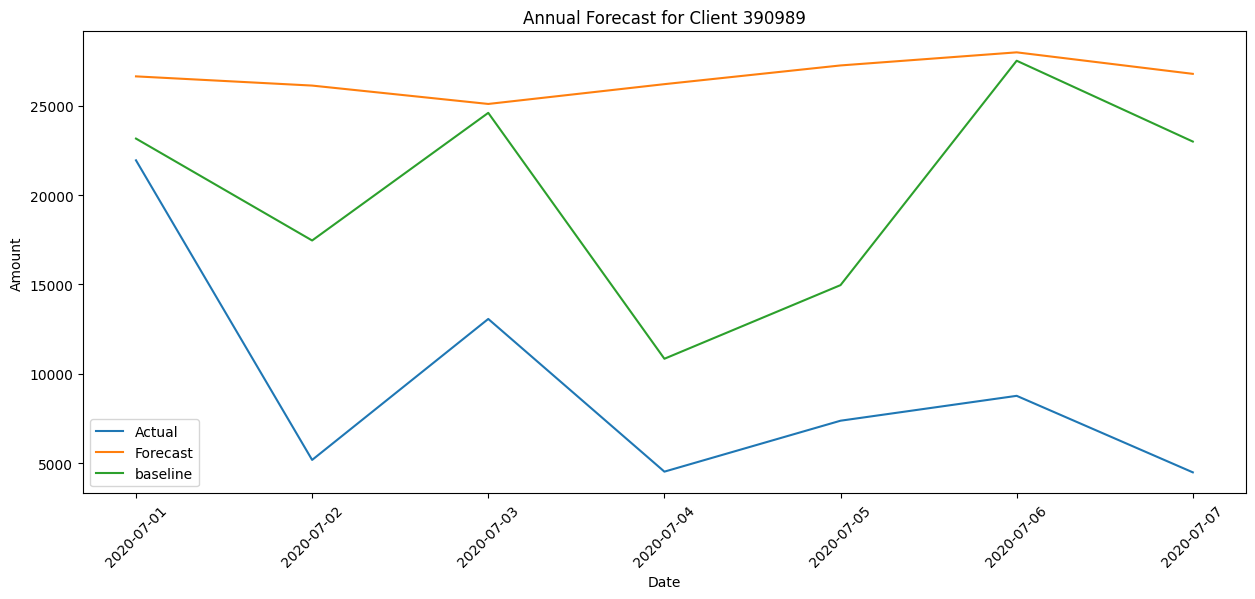

In [153]:
# Plotting
plt.figure(figsize=(15, 6))
plt.plot(forecast_dates, actual, label='Actual')
plt.plot(forecast_dates, predictions, label='Forecast')
plt.plot(forecast_dates, baseline_preds, label='baseline')
plt.title(f'Annual Forecast for Client {client_id}')
plt.xlabel('Date')

plt.ylabel('Amount')

plt.xticks(rotation=45)
plt.legend()
plt.show()


In [103]:
predictions

array([44727.96 , 33487.074, 36488.02 , 25256.562, 23614.275, 22682.184,
       32768.51 ], dtype=float32)

In [104]:
actual

array([  7947.35,   9703.19, 157343.24,  68463.88,  15369.88,      0.  ,
            0.  ])